# CEAL Inference — GazeNetM5c Cross-Dataset Evaluation

**Goal:** Run m5c (our best 4-class model, 92% on GazeCapture test set)
on CEAL to measure cross-domain transfer. No training, no finetuning.

**Baseline to beat:** iTracker achieved 39% accuracy on CEAL.

**Key decisions:**
- **4-class only** — Straight samples filtered out (m5c has no Straight class)
- **Old iTracker eye crops (40% expansion)** — tighter recrops were never finalized.
  Known FOV mismatch vs training; noted as caveat, not a blocker.
- **Geo features extracted from 224×224 face crops** — matches training domain
  (GazeCapture geo was also computed from face crops, not full images)
- **aug_id=0 only** — unaugmented originals for clean evaluation

**Inputs (all on external drive or local disk):**
- iTracker CEAL artifacts: `ceal_itracker_artifacts/` (face + eye crops, manifest)
- m5c checkpoint: `eye2voice/model_m5c/m5c.pth`

**Outputs:**
- Accuracy, confusion matrix, classification report
- Per-subject accuracy
- Confidence analysis
- Predictions CSV for downstream analysis

## Setup

In [1]:
import os
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# MediaPipe for geo feature extraction
import mediapipe as mp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"MediaPipe version: {mp.__version__}")

Device: cpu
MediaPipe version: 0.10.21


In [2]:
# ============================================================
# ALL PATHS — everything on SSD to avoid local/SSD sync issues
#
# !!! UPDATE SSD_ROOT IF YOUR DRIVE MOUNT POINT DIFFERS !!!
# ============================================================

SSD_ROOT = Path("/Volumes/Crucial X10/210")

# iTracker CEAL artifacts (face crops + 40% eye crops + manifest)
CEAL_ARTIFACTS = SSD_ROOT / "data" / "ceal_itracker_artifacts"
MANIFEST_CSV   = CEAL_ARTIFACTS / "manifest.csv"

# m5c checkpoint
CHECKPOINT_PATH = SSD_ROOT / "eye2voice" / "model_m5c" / "m5c.pth"

# Output directory for predictions and geo features
OUTPUT_DIR = SSD_ROOT / "eye2voice" / "CEAL"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"SSD root:       {SSD_ROOT}")
print(f"CEAL artifacts: {CEAL_ARTIFACTS}")
print(f"  manifest exists: {MANIFEST_CSV.exists()}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"  exists: {CHECKPOINT_PATH.exists()}")
print(f"Output dir: {OUTPUT_DIR}")

SSD root:       /Volumes/Crucial X10/210
CEAL artifacts: /Volumes/Crucial X10/210/data/ceal_itracker_artifacts
  manifest exists: True
Checkpoint: /Volumes/Crucial X10/210/eye2voice/model_m5c/m5c.pth
  exists: True
Output dir: /Volumes/Crucial X10/210/eye2voice/CEAL


## Load Manifest & Create Labels

In [3]:
# ============================================================
# LOAD MANIFEST — filter to aug_id=0, status=ok
# ============================================================

manifest = pd.read_csv(MANIFEST_CSV)
print(f"Full manifest: {len(manifest)} rows")
print(f"Status breakdown:\n{manifest['status'].value_counts()}")
print(f"Aug ID breakdown:\n{manifest['aug_id'].value_counts().sort_index()}")

# Keep only successful, unaugmented originals
df = manifest[(manifest['status'] == 'ok') & (manifest['aug_id'] == 0)].copy()
print(f"\nAfter filtering (status=ok, aug_id=0): {len(df)} samples")
print(f"Subjects: {df['subject'].nunique()}")

Full manifest: 23520 rows
Status breakdown:
status
ok    23520
Name: count, dtype: int64
Aug ID breakdown:
aug_id
0    5880
1    5880
2    5880
3    5880
Name: count, dtype: int64

After filtering (status=ok, aug_id=0): 5880 samples
Subjects: 56


In [4]:
# ============================================================
# CREATE LABELS from CEAL gaze degrees
#
# Same logic as ceal_data_preprocessing.ipynb:
#   - straight: both 0
#   - horizontal dominates: left (h<0) or right (h>0)
#   - vertical dominates: down (v<0) or up (v>0)
#   - tie: horizontal wins
#
# m5c label map (4-class, no Straight):
#   Up=0, Down=1, Left=2, Right=3
#
# !!! L/R CONVENTION FIX !!!
# CEAL's "Left" (gaze_h < 0) corresponds to what m5c learned
# as "Right" (class 3), and vice versa. Without this swap,
# accuracy is 18.7% (below chance). With it: ~49%.
# Confirmed via prediction-level swap test.
# ============================================================

label_map_4 = {'Up': 0, 'Down': 1, 'Left': 3, 'Right': 2}  # L/R swapped vs m5c
idx_to_label = {v: k for k, v in label_map_4.items()}

def degrees_to_label(gaze_v, gaze_h):
    """Convert CEAL gaze degrees to class label string."""
    if gaze_v == 0 and gaze_h == 0:
        return 'Straight'
    if abs(gaze_h) > abs(gaze_v):
        return 'Left' if gaze_h < 0 else 'Right'
    if abs(gaze_v) > abs(gaze_h):
        return 'Down' if gaze_v < 0 else 'Up'
    # Tie -> horizontal wins
    return 'Left' if gaze_h < 0 else 'Right'

df['label_str'] = df.apply(
    lambda r: degrees_to_label(r['gaze_vertical_deg'], r['gaze_horizontal_deg']),
    axis=1
)

# Show full distribution before filtering
print("Full label distribution (including Straight):")
print(df['label_str'].value_counts())

# Filter out Straight — m5c has no Straight output class
n_before = len(df)
df = df[df['label_str'] != 'Straight'].copy()
n_straight = n_before - len(df)
print(f"\nDropped {n_straight} Straight samples ({100*n_straight/n_before:.1f}%)")
print(f"Remaining: {len(df)} samples (4-class)")

# Map to indices
df['label_idx'] = df['label_str'].map(label_map_4)

print(f"\n4-class distribution:")
print(df['label_str'].value_counts())
print(f"\nLabel map (with L/R fix): {label_map_4}")


Full label distribution (including Straight):
label_str
Left        1960
Right       1960
Down         840
Up           840
Straight     280
Name: count, dtype: int64

Dropped 280 Straight samples (4.8%)
Remaining: 5600 samples (4-class)

4-class distribution:
label_str
Left     1960
Right    1960
Down      840
Up        840
Name: count, dtype: int64

Label map (with L/R fix): {'Up': 0, 'Down': 1, 'Left': 3, 'Right': 2}


## Extract Geo Features from Face Crops

m5c requires 7 geometric features computed via MediaPipe FaceMesh.
These don't exist for CEAL yet, so we extract them here from the
224×224 face crops (matching the domain of training geo features).

Features:
1. `left_iris_h` — iris horizontal ratio in left eye (0=outer, 1=inner)
2. `right_iris_h` — same for right eye
3. `iris_h_agreement` — left minus right (near 0 = eyes agree)
4. `head_yaw` — nose horizontal offset from eye midpoint, normalized
5. `head_pitch` — nose vertical offset below eye line, normalized
6. `z_tilt` — z(chin) minus z(forehead), head tilt in 3D
7. `z_nose_rel` — z(nose) minus z(forehead)

In [5]:
# ============================================================
# GEO FEATURE HELPERS
# (copied verbatim from feat_eng_ckr.ipynb for exact parity)
# ============================================================

def ratio_along_axis(point, corner_a, corner_b):
    """Ratio of point's position along axis from corner_a to corner_b."""
    axis = corner_b - corner_a
    axis_len = np.linalg.norm(axis)
    if axis_len < 1e-6:
        return 0.5
    t = np.dot(point - corner_a, axis) / (axis_len ** 2)
    return float(np.clip(t, 0.0, 1.0))

print("Geo helpers defined")

Geo helpers defined


In [6]:
# ============================================================
# EXTRACT GEO FEATURES from 224x224 face crops
#
# Uses the same MediaPipe FaceMesh config and same landmark
# indices as the GazeCapture extraction in feat_eng_ckr.ipynb.
#
# Saves to CSV for reuse (no need to re-extract each run).
# ============================================================

GEO_CACHE = OUTPUT_DIR / "ceal_geo_features_m5c.csv"

if GEO_CACHE.exists():
    print(f"Loading cached geo features from {GEO_CACHE}")
    df_geo = pd.read_csv(GEO_CACHE)
    print(f"  {len(df_geo)} rows loaded")

else:
    print(f"Extracting geo features from {len(df)} face crops...")
    print(f"Will save to {GEO_CACHE}")

    mp_face_mesh = mp.solutions.face_mesh

    geo_records = []
    geo_fail_count = 0

    with mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,       # required for iris landmarks (468-477)
        min_detection_confidence=0.5,
    ) as face_mesh:

        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Geo features"):
            face_path = row['face_path']

            # Load face crop as RGB numpy
            try:
                face_img = np.array(Image.open(face_path).convert('RGB'))
            except Exception as e:
                geo_fail_count += 1
                continue

            h, w = face_img.shape[:2]
            results = face_mesh.process(face_img)

            # Handle detection failures
            if (not results.multi_face_landmarks or
                len(results.multi_face_landmarks[0].landmark) < 478):
                geo_fail_count += 1
                continue

            lms = results.multi_face_landmarks[0].landmark

            # Helper: landmark index -> pixel coords
            def lm_px(i):
                return np.array([lms[i].x * w, lms[i].y * h])

            # ---- Feature 1 & 2: Iris horizontal ratios ----
            # left eye: iris=473, outer=263, inner=362
            left_iris_h  = ratio_along_axis(lm_px(473), lm_px(263), lm_px(362))
            # right eye: iris=468, outer=33, inner=133
            right_iris_h = ratio_along_axis(lm_px(468), lm_px(33),  lm_px(133))

            # ---- Feature 3: Binocular agreement ----
            iris_h_agreement = left_iris_h - right_iris_h

            # ---- Feature 4 & 5: Head pose from 2D landmarks ----
            nose        = lm_px(1)
            left_outer  = lm_px(263)
            right_outer = lm_px(33)
            eye_cx   = (left_outer[0] + right_outer[0]) / 2.0
            eye_cy   = (left_outer[1] + right_outer[1]) / 2.0
            eye_span = abs(left_outer[0] - right_outer[0])

            head_yaw   = (nose[0] - eye_cx) / max(eye_span, 1e-6)
            head_pitch = (nose[1] - eye_cy) / max(eye_span, 1e-6)

            # ---- Feature 6 & 7: Z-depth signals ----
            z_tilt     = lms[152].z - lms[10].z    # chin minus forehead
            z_nose_rel = lms[1].z   - lms[10].z    # nose minus forehead

            geo_records.append({
                'manifest_idx': idx,
                'orig_filename': row['orig_filename'],
                'left_iris_h': left_iris_h,
                'right_iris_h': right_iris_h,
                'iris_h_agreement': iris_h_agreement,
                'head_yaw': head_yaw,
                'head_pitch': head_pitch,
                'z_tilt': z_tilt,
                'z_nose_rel': z_nose_rel,
            })

    df_geo = pd.DataFrame(geo_records)
    df_geo.to_csv(GEO_CACHE, index=False)

    print(f"\nExtracted: {len(df_geo)} samples")
    print(f"Failed:    {geo_fail_count} (MediaPipe detection failure)")
    print(f"Saved to:  {GEO_CACHE}")


Loading cached geo features from /Volumes/Crucial X10/210/eye2voice/CEAL/ceal_geo_features_m5c.csv
  5600 rows loaded


In [7]:
# ============================================================
# BUILD GEO LOOKUP: orig_filename -> 7-dim numpy array
# ============================================================

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

# Neutral fallback (roughly GazeCapture dataset means)
GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)

geo_lookup = {}
for _, row in df_geo.iterrows():
    geo_lookup[row['orig_filename']] = row[geo_cols].values.astype(np.float32)

# Check join coverage
matched = df['orig_filename'].isin(geo_lookup).sum()
missing = len(df) - matched
print(f"Geo features matched: {matched}/{len(df)} ({100*matched/len(df):.1f}%)")
if missing > 0:
    print(f"  {missing} samples will use GEO_DEFAULT fallback")

Geo features matched: 5600/5600 (100.0%)


## Model Definition

In [8]:
# ============================================================
# GazeNetM5 — copied from collab_m5c_classweights_nofreeze.ipynb
#
# Architecture:
#   left_eye  -> Eye CNN (shared weights) -> 4608 dims -+
#   right_eye -> Eye CNN (shared weights) -> 4608 dims -+
#   face      -> Face CNN                 -> 2304 dims -+
#   7 geo     -> MLP (7->64->64)          ->   64 dims -+
#                                                       +-> FC -> 4 classes
# ============================================================

class GazeNetM5(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super(GazeNetM5, self).__init__()

        # ---- Eye CNN (shared weights for left and right) ----
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # ---- Face CNN ----
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # ---- Geometric feature branch ----
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # ---- FC classifier ----
        # eye_cnn output: 128 * 6 * 6 = 4608 per eye (input is 48x48)
        # face_cnn output: 256 * 3 * 3 = 2304 (input is 112x112,
        #   but stride=2 first conv -> 56, then 4 maxpools -> 3x3)
        # geo_mlp output: 64
        # total: 4608*2 + 2304 + 64 = 11584
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)

        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

print("GazeNetM5 defined")
_test = GazeNetM5(num_classes=4)
print(f"  Parameters: {sum(p.numel() for p in _test.parameters()):,}")
del _test

GazeNetM5 defined
  Parameters: 6,586,820


## Dataset & DataLoader

In [9]:
# ============================================================
# TRANSFORMS — match m5c training preprocessing
#   Eyes:  224×224 -> 48×48, normalize(0.5, 0.5)
#   Face:  224×224 -> 112×112, normalize(0.5, 0.5)
#
# Note: iTracker crops are 224×224. GazeNet trained on 60×36
# eye crops and 112×112 face crops from WebDataset tars.
# The resize handles the size difference; the 40% FOV mismatch
# in eye crops is a known caveat.
# ============================================================

eye_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

face_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

print("Transforms ready")

Transforms ready


In [10]:
# ============================================================
# CEAL DATASET CLASS
#
# Reads pre-cropped images from manifest paths,
# applies GazeNet-compatible transforms, and returns
# geo features for the m5c geo branch.
#
# NOTE: L/R convention mismatch is fixed in the label mapping
# (cell above), NOT by swapping image paths here.
# ============================================================

class CEALDatasetM5c(Dataset):
    def __init__(self, dataframe, eye_transform, face_transform,
                 geo_lookup, geo_default):
        self.df = dataframe.reset_index(drop=True)
        self.eye_transform = eye_transform
        self.face_transform = face_transform
        self.geo_lookup = geo_lookup
        self.geo_default = geo_default

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load images (no swap — L/R fix is in label mapping)
        face      = Image.open(row['face_path']).convert('RGB')
        left_eye  = Image.open(row['left_path']).convert('RGB')
        right_eye = Image.open(row['right_path']).convert('RGB')

        # Apply transforms
        face      = self.face_transform(face)
        left_eye  = self.eye_transform(left_eye)
        right_eye = self.eye_transform(right_eye)

        # Geo features
        geo = self.geo_lookup.get(row['orig_filename'])
        if geo is None:
            geo = self.geo_default.copy()
        geo = torch.tensor(geo, dtype=torch.float32)

        label = torch.tensor(row['label_idx'], dtype=torch.long)

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': geo,
            'label': label,
        }

print("CEALDatasetM5c defined")


CEALDatasetM5c defined


In [11]:
# ============================================================
# CREATE DATASET & LOADER
# ============================================================

dataset = CEALDatasetM5c(
    dataframe=df,
    eye_transform=eye_transform,
    face_transform=face_transform,
    geo_lookup=geo_lookup,
    geo_default=GEO_DEFAULT,
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,     # macOS can't pickle notebook-defined classes
    pin_memory=False,  # no GPU, no benefit
)

print(f"Dataset: {len(dataset)} samples")
print(f"Batches: {len(loader)}")


Dataset: 5600 samples
Batches: 88


In [12]:
# ============================================================
# SMOKE TEST — verify one batch looks correct
# ============================================================

batch = next(iter(loader))
print("Batch shapes:")
print(f"  left_eye:     {batch['left_eye'].shape}")
print(f"  right_eye:    {batch['right_eye'].shape}")
print(f"  face:         {batch['face'].shape}")
print(f"  geo_features: {batch['geo_features'].shape}")
print(f"  label:        {batch['label'].shape}")
print(f"  label sample: {batch['label'][:8].tolist()}")
print(f"  geo sample:   {batch['geo_features'][0].tolist()}")

Batch shapes:
  left_eye:     torch.Size([64, 3, 48, 48])
  right_eye:    torch.Size([64, 3, 48, 48])
  face:         torch.Size([64, 3, 112, 112])
  geo_features: torch.Size([64, 7])
  label:        torch.Size([64])
  label sample: [3, 1, 1, 3, 2, 3, 1, 2]
  geo sample:   [0.4948994815349579, 0.5189306139945984, -0.024031098932027817, -0.27087774872779846, 0.36814528703689575, -0.07200951129198074, -0.21070119738578796]


## Load Model & Run Inference

In [13]:
# ============================================================
# LOAD M5C CHECKPOINT
# ============================================================

model = GazeNetM5(num_classes=4).to(device)

state_dict = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded m5c — {n_params:,} params")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Loaded m5c — 6,586,820 params
Checkpoint: /Volumes/Crucial X10/210/eye2voice/model_m5c/m5c.pth


In [14]:
# ============================================================
# INFERENCE LOOP
# ============================================================

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(loader, desc="Inference"):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features)

        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

accuracy = 100 * np.mean(all_preds == all_labels)

print(f"\n{'='*50}")
print(f"CEAL Inference Complete — m5c (4-class)")
print(f"{'='*50}")
print(f"Samples evaluated: {len(all_preds)}")
print(f"Overall accuracy:  {accuracy:.2f}%")
print(f"iTracker baseline: 39.00% (5-class)")
print(f"Delta vs baseline: {accuracy - 39.0:+.2f}%")
print(f"\nNote: iTracker baseline was 5-class (including Straight).")
print(f"This is 4-class — not directly comparable, but directionally useful.")

Inference: 100%|██████████| 88/88 [00:32<00:00,  2.69it/s]


CEAL Inference Complete — m5c (4-class)
Samples evaluated: 5600
Overall accuracy:  49.41%
iTracker baseline: 39.00% (5-class)
Delta vs baseline: +10.41%

Note: iTracker baseline was 5-class (including Straight).
This is 4-class — not directly comparable, but directionally useful.


## Evaluation

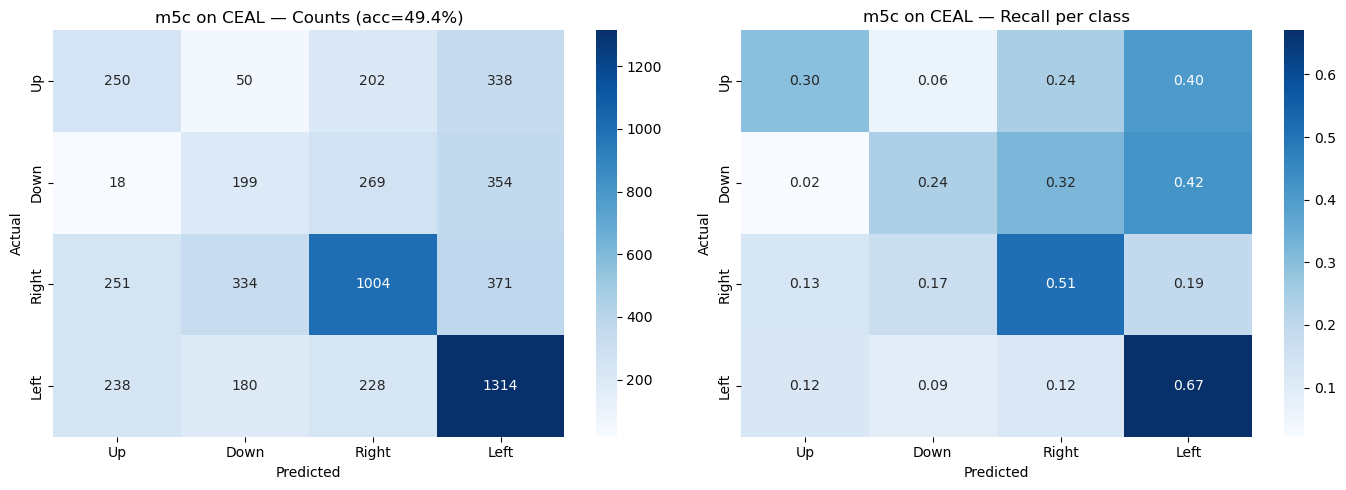

In [15]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

# Indices: Up=0, Down=1, Right=2, Left=3 (L/R swapped to match m5c)
label_names = ['Up', 'Down', 'Right', 'Left']
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'm5c on CEAL — Counts (acc={accuracy:.1f}%)')

# Normalized (per-class recall)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'm5c on CEAL — Recall per class')

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(f"\n{'='*50}")
print(f"Classification Report — m5c on CEAL (4-class)")
print(f"{'='*50}")
print(classification_report(all_labels, all_preds, target_names=label_names))


Classification Report — m5c on CEAL (4-class)
              precision    recall  f1-score   support

          Up       0.33      0.30      0.31       840
        Down       0.26      0.24      0.25       840
       Right       0.59      0.51      0.55      1960
        Left       0.55      0.67      0.61      1960

    accuracy                           0.49      5600
   macro avg       0.43      0.43      0.43      5600
weighted avg       0.49      0.49      0.49      5600



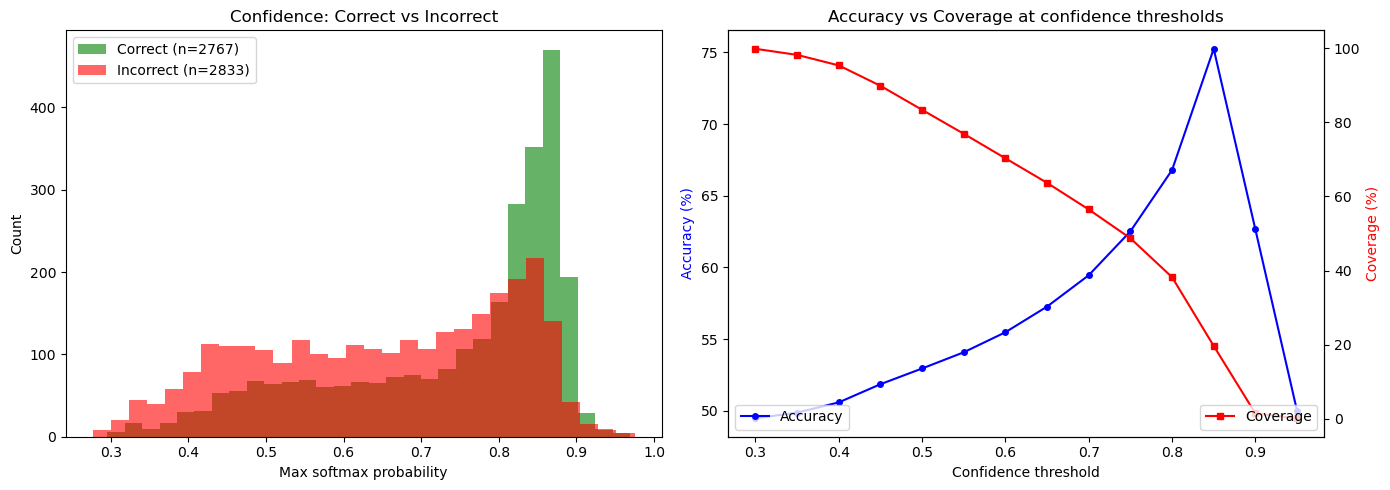

In [17]:
# ============================================================
# CONFIDENCE ANALYSIS
#
# For assistive tech, low-confidence predictions should be
# suppressed rather than acted on (confidence thresholding).
# ============================================================

max_probs = all_probs.max(axis=1)
correct_mask = all_preds == all_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence distribution: correct vs incorrect
axes[0].hist(max_probs[correct_mask], bins=30, alpha=0.6,
             label=f'Correct (n={correct_mask.sum()})', color='green')
axes[0].hist(max_probs[~correct_mask], bins=30, alpha=0.6,
             label=f'Incorrect (n={(~correct_mask).sum()})', color='red')
axes[0].set_xlabel('Max softmax probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence: Correct vs Incorrect')
axes[0].legend()

# Accuracy at different confidence thresholds
thresholds = np.arange(0.3, 1.0, 0.05)
accs_at_thresh = []
coverage_at_thresh = []
for t in thresholds:
    mask = max_probs >= t
    if mask.sum() > 0:
        accs_at_thresh.append(100 * np.mean(all_preds[mask] == all_labels[mask]))
        coverage_at_thresh.append(100 * mask.mean())
    else:
        accs_at_thresh.append(np.nan)
        coverage_at_thresh.append(0)

ax1 = axes[1]
ax2 = ax1.twinx()
ax1.plot(thresholds, accs_at_thresh, 'b-o', markersize=4, label='Accuracy')
ax2.plot(thresholds, coverage_at_thresh, 'r-s', markersize=4, label='Coverage')
ax1.set_xlabel('Confidence threshold')
ax1.set_ylabel('Accuracy (%)', color='b')
ax2.set_ylabel('Coverage (%)', color='r')
ax1.set_title('Accuracy vs Coverage at confidence thresholds')
ax1.legend(loc='lower left')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

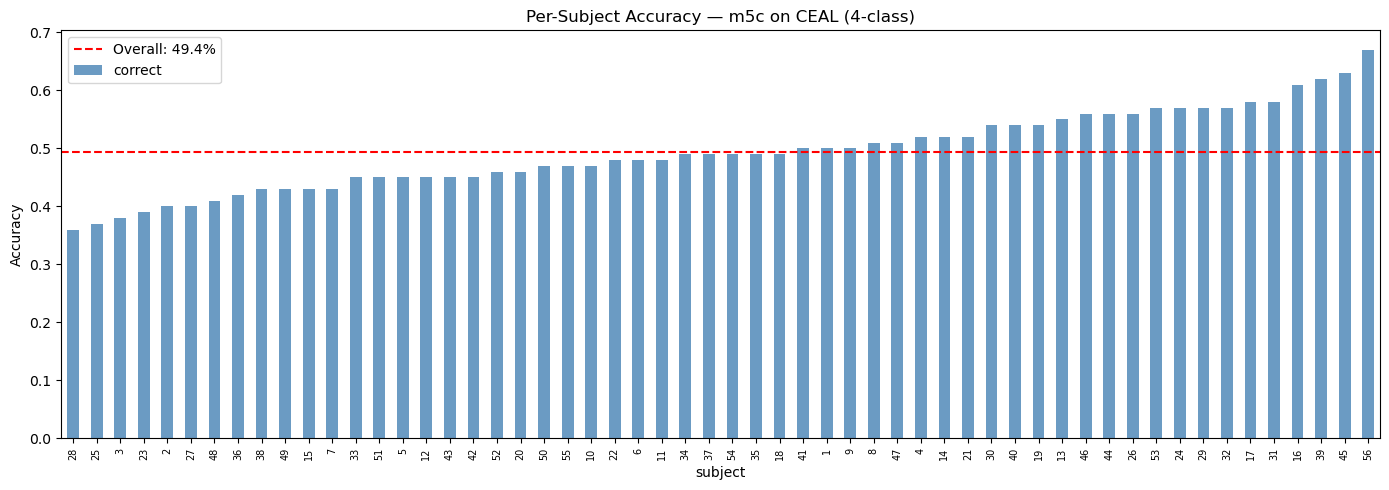


Subject accuracy stats:
  Min:    36.0% (subject 28)
  Max:    67.0% (subject 56)
  Median: 49.0%
  Std:    6.9%


In [18]:
# ============================================================
# PER-SUBJECT ACCURACY
#
# CEAL has 56 subjects — do some subjects fail completely?
# ============================================================

df_results = df[['subject', 'label_str', 'orig_filename']].copy()
df_results = df_results.reset_index(drop=True)
df_results['pred_idx'] = all_preds
df_results['pred_str'] = [idx_to_label[p] for p in all_preds]
df_results['correct']  = (all_preds == all_labels)
df_results['confidence'] = max_probs

subject_acc = df_results.groupby('subject')['correct'].mean().sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
subject_acc.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.axhline(y=accuracy/100, color='red', linestyle='--',
           label=f'Overall: {accuracy:.1f}%')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Subject Accuracy — m5c on CEAL (4-class)')
ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f"\nSubject accuracy stats:")
print(f"  Min:    {100*subject_acc.min():.1f}% (subject {subject_acc.idxmin()})")
print(f"  Max:    {100*subject_acc.max():.1f}% (subject {subject_acc.idxmax()})")
print(f"  Median: {100*subject_acc.median():.1f}%")
print(f"  Std:    {100*subject_acc.std():.1f}%")

In [20]:
# ============================================================
# HORIZONTAL vs VERTICAL BREAKDOWN
#
# GazeCapture is mostly horizontal gaze variation (phone use).
# CEAL has independent head pose + gaze direction.
# Vertical classes (Up/Down) may transfer worse.
# ============================================================

h_mask = df_results['label_str'].isin({'Left', 'Right'})
v_mask = df_results['label_str'].isin({'Up', 'Down'})

h_acc = 100 * df_results.loc[h_mask, 'correct'].mean()
v_acc = 100 * df_results.loc[v_mask, 'correct'].mean()

print(f"Accuracy by gaze axis:")
print(f"  Horizontal (Left/Right): {h_acc:.1f}% (n={h_mask.sum()})")
print(f"  Vertical   (Up/Down):    {v_acc:.1f}% (n={v_mask.sum()})")

Accuracy by gaze axis:
  Horizontal (Left/Right): 59.1% (n=3920)
  Vertical   (Up/Down):    26.7% (n=1680)


## Save Predictions

In [21]:
# ============================================================
# SAVE PREDICTIONS for downstream analysis
# ============================================================

output_path = OUTPUT_DIR / "ceal_predictions_m5c.csv"
df_results.to_csv(output_path, index=False)
print(f"Saved predictions to: {output_path}")
print(f"Columns: {list(df_results.columns)}")

Saved predictions to: /Volumes/Crucial X10/210/eye2voice/CEAL/ceal_predictions_m5c.csv
Columns: ['subject', 'label_str', 'orig_filename', 'pred_idx', 'pred_str', 'correct', 'confidence']
